In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split, Subset
from torchvision import transforms
from PIL import Image
from sklearn.metrics import confusion_matrix, accuracy_score, precision_recall_fscore_support
from sklearn.model_selection import KFold
import seaborn as sns
import pandas as pd

# Tente importar kagglehub, mas não falhe se não estiver disponível (para flexibilidade fora do Kaggle)
try:
    import kagglehub
    KAGGLEHUB_AVAILABLE = True
except ImportError:
    KAGGLEHUB_AVAILABLE = False
    print("Aviso: kagglehub não encontrado. O download do dataset pode precisar ser manual.")

In [ ]:
# --- CÉLULA 1: Importações, Configurações, Definições de Dados e Modelos ---

# Configurações gerais
if KAGGLEHUB_AVAILABLE:
    try:
        path = kagglehub.dataset_download("hasibalmuzdadid/shoe-vs-sandal-vs-boot-dataset-15k-images")
        data_dir = os.path.join(path, 'Shoe vs Sandal vs Boot Dataset')
    except Exception as e:
        print(f"Erro ao baixar o dataset do Kaggle Hub: {e}")
        print("Por favor, defina 'data_dir' manualmente para o caminho do seu dataset.")
        data_dir = "./Shoe vs Sandal vs Boot Dataset" # Exemplo, ajuste conforme necessário
else:
    print("Por favor, defina 'data_dir' manualmente para o caminho do seu dataset.")
    data_dir = "./Shoe vs Sandal vs Boot Dataset" # Exemplo, ajuste conforme necessário

classes = ['Boot', 'Sandal', 'Shoe']
img_size = (128, 128)
batch_size = 32
kfold_epochs = 1      # Número de épocas para o k-fold (AJUSTADO PARA 1).
individual_train_epochs = 20 # Número de épocas para o treino individual.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
k_folds = 5

output_graphics_dir = "./graficos_output"
os.makedirs(output_graphics_dir, exist_ok=True)

print(f"Usando dispositivo: {device}")
print(f"Diretório de dados (esperado): {data_dir}")
print(f"Diretório de gráficos: {output_graphics_dir}")

all_models_final_test_metrics = {} # Dicionário para armazenar métricas de teste finais de todos os modelos

data_transforms = transforms.Compose([
    transforms.Resize(img_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class FootwearDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data = []
        self.transform = transform
        self.classes = classes
        for class_idx, class_name in enumerate(self.classes):
            class_path = os.path.join(data_dir, class_name)
            if not os.path.isdir(class_path):
                print(f"Aviso: Diretório da classe {class_name} não encontrado em {class_path}")
                continue
            for img_name in os.listdir(class_path):
                img_path = os.path.join(class_path, img_name)
                if img_path.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif')):
                    self.data.append((img_path, class_idx))
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        img_path, class_idx = self.data[idx]
        try:
            img = Image.open(img_path).convert('RGB')
            if self.transform:
                img = self.transform(img)
            return img, class_idx
        except Exception as e:
            print(f"Erro ao carregar imagem {img_path}: {e}")
            return torch.zeros((3, img_size[0], img_size[1])), -1

dataset = FootwearDataset(data_dir, transform=data_transforms)
dataset.data = [(img_path, label) for img_path, label in dataset.data
                if not (isinstance(label, int) and label == -1 and
                        isinstance(img_path, torch.Tensor) and img_path.shape == (3, img_size[0], img_size[1]))]

if len(dataset) == 0:
    print("ERRO: Nenhum dado carregado.")
else:
    print(f"Dataset carregado com {len(dataset)} imagens.")

if len(dataset) > 1:
    train_val_size = int(0.85 * len(dataset))
    test_size = len(dataset) - train_val_size
    if test_size == 0:
        if len(dataset) > 1:
            train_val_size = len(dataset) -1
            test_size = 1
        else:
            train_val_dataset = dataset
            test_dataset = Subset(dataset, [])
    else:
        train_val_dataset, test_dataset = random_split(dataset, [train_val_size, test_size],
                                                       generator=torch.Generator().manual_seed(42))
else:
    train_val_dataset = dataset
    test_dataset = Subset(dataset, [])

print(f"Tamanho do dataset de treino/validação: {len(train_val_dataset)}")
print(f"Tamanho do dataset de teste: {len(test_dataset)}")

if len(test_dataset) > 0:
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True if device.type=='cuda' else False)
else:
    test_loader = None
    print("Aviso: Conjunto de teste está vazio.")

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=3):
        super(SimpleCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2)
        )
        self._fc_input_features = 64 * (img_size[0] // 8) * (img_size[1] // 8)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(self._fc_input_features, 128), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )
    def forward(self, x):
        return self.classifier(self.features(x))

class LightCNN(nn.Module):
    def __init__(self, num_classes=3):
        super(LightCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, num_classes)
        )
    def forward(self, x):
        return self.classifier(self.features(x))

class MiniMobileNetV2(nn.Module):
    def __init__(self, num_classes=3):
        super(MiniMobileNetV2, self).__init__()
        def conv_bn(inp, oup, stride):
            return nn.Sequential(nn.Conv2d(inp, oup, 3, stride, 1, bias=False), nn.BatchNorm2d(oup), nn.ReLU6(inplace=True))
        class InvertedResidual(nn.Module):
            def __init__(self, inp, oup, stride, expand_ratio):
                super().__init__()
                self.stride = stride
                hidden_dim = int(inp * expand_ratio)
                self.use_res_connect = self.stride == 1 and inp == oup
                layers = []
                if expand_ratio != 1:
                    layers.append(nn.Conv2d(inp, hidden_dim, 1, 1, 0, bias=False))
                    layers.append(nn.BatchNorm2d(hidden_dim))
                    layers.append(nn.ReLU6(inplace=True))
                layers.extend([
                    nn.Conv2d(hidden_dim, hidden_dim, 3, stride, 1, groups=hidden_dim, bias=False), nn.BatchNorm2d(hidden_dim), nn.ReLU6(inplace=True),
                    nn.Conv2d(hidden_dim, oup, 1, 1, 0, bias=False), nn.BatchNorm2d(oup),
                ])
                self.conv = nn.Sequential(*layers)
            def forward(self, x):
                return x + self.conv(x) if self.use_res_connect else self.conv(x)
        input_channel = 32
        last_channel = 128
        self.features = nn.Sequential(
            conv_bn(3, input_channel, 2),
            InvertedResidual(input_channel, 16, 1, 1),
            InvertedResidual(16, 24, 2, 6),
            InvertedResidual(24, 32, 2, 6),
            InvertedResidual(32, 64, 2, 6),
            nn.Conv2d(64, last_channel, 1, 1, 0, bias=False), nn.BatchNorm2d(last_channel), nn.ReLU6(inplace=True),
            nn.AdaptiveAvgPool2d(1), nn.Flatten()
        )
        self.classifier = nn.Sequential(nn.Dropout(0.2), nn.Linear(last_channel, num_classes))
    def forward(self, x):
        return self.classifier(self.features(x))

def train_kfold(model_class, current_train_val_dataset, current_k_folds, num_epochs_per_fold, current_batch_size, current_device, model_name_str):
    kfold = KFold(n_splits=current_k_folds, shuffle=True, random_state=42)
    fold_results_list = []
    all_fold_histories = []
    dataset_indices = list(range(len(current_train_val_dataset)))
    for fold, (train_ids, val_ids) in enumerate(kfold.split(dataset_indices)):
        print(f'\nMODEL: {model_name_str} - FOLD {fold+1}/{current_k_folds}')
        train_subset = Subset(current_train_val_dataset, train_ids)
        val_subset = Subset(current_train_val_dataset, val_ids)
        current_train_loader = DataLoader(train_subset, batch_size=current_batch_size, shuffle=True, num_workers=2, pin_memory=True if current_device.type=='cuda' else False)
        current_val_loader = DataLoader(val_subset, batch_size=current_batch_size, shuffle=False, num_workers=2, pin_memory=True if current_device.type=='cuda' else False)
        model_instance = model_class(num_classes=len(classes)).to(current_device)
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model_instance.parameters(), lr=0.001)
        history_this_fold = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
        for epoch_num in range(num_epochs_per_fold):
            model_instance.train()
            running_loss, running_corrects = 0.0, 0
            for inputs, labels in current_train_loader:
                inputs, labels = inputs.to(current_device), labels.to(current_device)
                if labels.min() < 0: continue
                optimizer.zero_grad()
                outputs = model_instance(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                running_loss += loss.item() * inputs.size(0)
                preds = outputs.argmax(dim=1)
                running_corrects += torch.sum(preds == labels).item()
            epoch_loss = running_loss / len(train_subset) if len(train_subset) > 0 else 0
            epoch_acc = running_corrects / len(train_subset) if len(train_subset) > 0 else 0
            model_instance.eval()
            val_running_loss, val_running_corrects = 0.0, 0
            with torch.no_grad():
                for inputs, labels in current_val_loader:
                    inputs, labels = inputs.to(current_device), labels.to(current_device)
                    if labels.min() < 0: continue
                    outputs = model_instance(inputs)
                    loss = criterion(outputs, labels)
                    val_running_loss += loss.item() * inputs.size(0)
                    preds = outputs.argmax(dim=1)
                    val_running_corrects += torch.sum(preds == labels).item()
            epoch_val_loss = val_running_loss / len(val_subset) if len(val_subset) > 0 else 0
            epoch_val_acc = val_running_corrects / len(val_subset) if len(val_subset) > 0 else 0
            history_this_fold['train_loss'].append(epoch_loss)
            history_this_fold['train_acc'].append(epoch_acc)
            history_this_fold['val_loss'].append(epoch_val_loss)
            history_this_fold['val_acc'].append(epoch_val_acc)
            print(f'Epoch {epoch_num+1}/{num_epochs_per_fold} | Train loss: {epoch_loss:.4f}, Train acc: {epoch_acc:.4f} | Val loss: {epoch_val_loss:.4f}, Val acc: {epoch_val_acc:.4f}')
        all_fold_histories.append(history_this_fold)
        model_instance.eval()
        val_preds, val_labels_list = [], []
        with torch.no_grad():
            for inputs, labels in current_val_loader:
                if labels.min() < 0: continue
                outputs = model_instance(inputs.to(current_device))
                val_preds.extend(outputs.argmax(dim=1).cpu().numpy())
                val_labels_list.extend(labels.numpy())
        if val_labels_list and val_preds:
            acc = accuracy_score(val_labels_list, val_preds)
            precision, recall, f1, _ = precision_recall_fscore_support(val_labels_list, val_preds, average='weighted', zero_division=0)
            fold_results_list.append({'fold': fold + 1, 'accuracy': acc, 'precision': precision, 'recall': recall, 'f1': f1})
            print(f'FOLD {fold+1} VALIDATION RESULTS: Accuracy: {acc:.4f} - Precision: {precision:.4f} - Recall: {recall:.4f} - F1: {f1:.4f}')
        else:
            fold_results_list.append({'fold': fold + 1, 'accuracy': 0, 'precision': 0, 'recall': 0, 'f1': 0})
    return fold_results_list, all_fold_histories

def evaluate_model(model, current_test_loader, current_device, model_name_str):
    if not current_test_loader: return 0,0,0,0, np.zeros((len(classes), len(classes)))
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in current_test_loader:
            inputs = inputs.to(current_device)
            if labels.min() < 0: continue
            outputs = model(inputs)
            all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
            all_labels.extend(labels.numpy())
    if not all_labels or not all_preds: return 0,0,0,0, np.zeros((len(classes), len(classes)))
    acc = accuracy_score(all_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='weighted', zero_division=0)
    cm = confusion_matrix(all_labels, all_preds, labels=list(range(len(classes))))
    return acc, precision, recall, f1, cm

def plot_kfold_metrics_summary(model_name, fold_results_list, all_fold_histories_for_model, num_total_folds, save_dir):
    if not fold_results_list or len(fold_results_list) != num_total_folds: return
    if not all_fold_histories_for_model or len(all_fold_histories_for_model) != num_total_folds: return
    folds_range = range(1, num_total_folds + 1)
    train_losses = [h['train_loss'][0] for h in all_fold_histories_for_model if h.get('train_loss') and len(h['train_loss']) > 0]
    val_losses = [h['val_loss'][0] for h in all_fold_histories_for_model if h.get('val_loss') and len(h['val_loss']) > 0]
    train_accs = [h['train_acc'][0] for h in all_fold_histories_for_model if h.get('train_acc') and len(h['train_acc']) > 0]
    val_accuracies = [r['accuracy'] for r in fold_results_list]
    val_precisions = [r['precision'] for r in fold_results_list]
    val_recalls = [r['recall'] for r in fold_results_list]
    val_f1s = [r['f1'] for r in fold_results_list]
    if not (len(train_losses) == num_total_folds and len(val_losses) == num_total_folds and len(train_accs) == num_total_folds and len(val_accuracies) == num_total_folds and len(val_precisions) == num_total_folds and len(val_recalls) == num_total_folds and len(val_f1s) == num_total_folds):
        print(f"Aviso: Inconsistência no K-Fold para {model_name}.")
        return
    plt.figure(figsize=(15, 12))
    plt.subplot(2, 2, 1)
    plt.plot(folds_range, train_losses, 'o-', label='Train Loss (per Fold)')
    plt.plot(folds_range, val_losses, 'o-', label='Validation Loss (per Fold)')
    plt.xlabel('Fold Number'); plt.ylabel('Loss'); plt.title(f'{model_name} - K-Fold Losses (1 Epoch/Fold)'); plt.xticks(folds_range); plt.legend(); plt.grid(True)
    plt.subplot(2, 2, 2)
    plt.plot(folds_range, train_accs, 'o-', label='Train Accuracy (per Fold)')
    plt.plot(folds_range, val_accuracies, 'o-', label='Validation Accuracy (per Fold)')
    plt.xlabel('Fold Number'); plt.ylabel('Accuracy'); plt.title(f'{model_name} - K-Fold Accuracies (1 Epoch/Fold)'); plt.xticks(folds_range); plt.legend(); plt.grid(True)
    plt.subplot(2, 2, 3)
    plt.plot(folds_range, val_precisions, 'o-', label='Validation Precision')
    plt.plot(folds_range, val_recalls, 'o-', label='Validation Recall')
    plt.plot(folds_range, val_f1s, 'o-', label='Validation F1-Score')
    plt.xlabel('Fold Number'); plt.ylabel('Score'); plt.title(f'{model_name} - K-Fold Validation Metrics (1 Epoch/Fold)'); plt.xticks(folds_range); plt.legend(); plt.grid(True)
    plt.suptitle(f'K-Fold Performance: {model_name} ({num_total_folds} Folds, 1 Epoch/Fold)', fontsize=16); plt.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()

def plot_individual_train_metrics(model_name, history, num_epochs, save_dir):
    epochs_range = range(1, num_epochs + 1)
    plt.figure(figsize=(15, 6))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, history['train_loss'], 'o-', label='Train Loss')
    title_suffix_loss = "Training Loss"
    if 'val_loss' in history and history['val_loss']:
        if len(history['val_loss']) == num_epochs:
            plt.plot(epochs_range, history['val_loss'], 'o-', label='Validation Loss')
            title_suffix_loss = "Training & Validation Loss"
        else: print(f"Nota: Dados de perda de validação para {model_name} incompletos.")
    else: print(f"Nota: Métricas de perda de validação não disponíveis para {model_name}.")
    plt.title(f'{model_name} - {title_suffix_loss} ({num_epochs} Epochs)'); plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.legend(loc='upper right'); plt.grid(True)
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, history['train_acc'], 'o-', label='Train Accuracy')
    title_suffix_acc = "Training Accuracy"
    if 'val_acc' in history and history['val_acc']:
        if len(history['val_acc']) == num_epochs:
            plt.plot(epochs_range, history['val_acc'], 'o-', label='Validation Accuracy')
            title_suffix_acc = "Training & Validation Accuracy"
        else: print(f"Nota: Dados de acurácia de validação para {model_name} incompletos.")
    else: print(f"Nota: Métricas de acurácia de validação não disponíveis para {model_name}.")
    plt.title(f'{model_name} - {title_suffix_acc} ({num_epochs} Epochs)'); plt.xlabel('Epochs'); plt.ylabel('Accuracy'); plt.legend(loc='lower right'); plt.grid(True)
    plt.tight_layout(); plt.show()

def plot_confusion_matrix_func(cm, class_names, model_name, save_dir, context_str="Teste"):
    plt.figure(figsize=(8, 6)); sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted'); plt.ylabel('True'); plt.title(f'Confusion Matrix - {model_name} ({context_str})'); plt.show()

def plot_final_epoch_train_val_metrics_bar_chart(model_name, final_train_loss, final_val_loss, final_train_acc, final_val_acc):
    metrics = ['Loss', 'Accuracy']
    train_values = [final_train_loss, final_train_acc]
    val_values_available = final_val_loss is not None and final_val_acc is not None
    if val_values_available:
        val_values = [final_val_loss, final_val_acc]

    x = np.arange(len(metrics))
    width = 0.35
    fig, ax = plt.subplots(figsize=(10, 6))
    rects1 = ax.bar(x - width/2 if val_values_available else x, train_values, width, label='Train Final')
    if val_values_available:
        rects2 = ax.bar(x + width/2, val_values, width, label='Validation Final')

    ax.set_ylabel('Scores')
    ax.set_title(f'{model_name} - Final Epoch Metrics: Train vs Validation')
    ax.set_xticks(x); ax.set_xticklabels(metrics); ax.legend()
    def autolabel(rects_list):
        for rects in rects_list:
            for rect in rects:
                height = rect.get_height()
                ax.annotate(f'{height:.4f}', xy=(rect.get_x() + rect.get_width() / 2, height), xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')
    autolabel([rects1])
    if val_values_available: autolabel([rects2])
    fig.tight_layout(); plt.show()

def plot_model_comparison_test_metrics_bar_chart(model_names_list, test_metrics_data):
    metrics_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    metric_keys = ['acc', 'precision', 'recall', 'f1']
    num_models = len(model_names_list)
    num_metrics = len(metrics_labels)
    data_for_plotting = np.zeros((num_models, num_metrics))
    for i, model_name in enumerate(model_names_list):
        if model_name in test_metrics_data:
            for j, key in enumerate(metric_keys):
                data_for_plotting[i, j] = test_metrics_data[model_name].get(key, 0)
    x = np.arange(num_metrics)
    width = 0.8 / num_models
    fig, ax = plt.subplots(figsize=(14, 8))
    for i, model_name in enumerate(model_names_list):
        rects = ax.bar(x + i * width - (width * (num_models -1) / 2) , data_for_plotting[i, :], width, label=model_name)
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.3f}', xy=(rect.get_x() + rect.get_width() / 2, height), xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)
    ax.set_ylabel('Scores'); ax.set_title('Comparação de Métricas de Teste Finais Entre Modelos'); ax.set_xticks(x); ax.set_xticklabels(metrics_labels); ax.legend(title="Modelos"); ax.grid(axis='y', linestyle='--'); plt.ylim(0, max(1.1, np.max(data_for_plotting) * 1.1 if data_for_plotting.size > 0 else 1.1 )); fig.tight_layout(); plt.show()

def train_evaluate_individual_model(model_class, model_name_str, original_train_val_dataset, current_test_loader, current_device, num_epochs, current_batch_size, current_output_graphics_dir, val_split_ratio=0.2):
    print(f"\n--- Treinando {model_name_str} individualmente por {num_epochs} épocas ---")
    if val_split_ratio > 0 and len(original_train_val_dataset) > 1:
        internal_val_size = int(len(original_train_val_dataset) * val_split_ratio)
        internal_train_size = len(original_train_val_dataset) - internal_val_size
        if internal_val_size == 0 or internal_train_size == 0:
            internal_train_dataset = original_train_val_dataset; internal_val_dataset = None
        else:
            internal_train_dataset, internal_val_dataset = random_split(original_train_val_dataset, [internal_train_size, internal_val_size], generator=torch.Generator().manual_seed(42))
            print(f"Divisão interna: {len(internal_train_dataset)} treino, {len(internal_val_dataset)} validação.")
    else:
        internal_train_dataset = original_train_val_dataset; internal_val_dataset = None
    model_instance = model_class(num_classes=len(classes)).to(current_device)
    criterion = nn.CrossEntropyLoss(); optimizer = optim.Adam(model_instance.parameters(), lr=0.001)
    internal_train_loader = DataLoader(internal_train_dataset, batch_size=current_batch_size, shuffle=True, num_workers=2, pin_memory=True if current_device.type=='cuda' else False)
    if internal_val_dataset and len(internal_val_dataset) > 0:
        internal_val_loader = DataLoader(internal_val_dataset, batch_size=current_batch_size, shuffle=False, num_workers=2, pin_memory=True if current_device.type=='cuda' else False)
        individual_history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    else:
        internal_val_loader = None; individual_history = {'train_loss': [], 'train_acc': []}
    for epoch in range(num_epochs):
        model_instance.train(); running_loss = 0.0; running_corrects = 0
        for inputs, labels in internal_train_loader:
            inputs, labels = inputs.to(current_device), labels.to(current_device)
            if labels.min() < 0: continue
            optimizer.zero_grad(); outputs = model_instance(inputs); loss = criterion(outputs, labels); loss.backward(); optimizer.step()
            running_loss += loss.item() * inputs.size(0); preds = outputs.argmax(dim=1); running_corrects += torch.sum(preds == labels).item()
        epoch_loss = running_loss / len(internal_train_dataset) if len(internal_train_dataset) > 0 else 0
        epoch_acc = running_corrects / len(internal_train_dataset) if len(internal_train_dataset) > 0 else 0
        individual_history['train_loss'].append(epoch_loss); individual_history['train_acc'].append(epoch_acc)
        epoch_val_loss_str, epoch_val_acc_str = "N/A", "N/A"
        if internal_val_loader:
            model_instance.eval(); val_running_loss, val_running_corrects = 0.0, 0
            with torch.no_grad():
                for inputs, labels in internal_val_loader:
                    inputs, labels = inputs.to(current_device), labels.to(current_device)
                    if labels.min() < 0: continue
                    outputs = model_instance(inputs); loss = criterion(outputs, labels); val_running_loss += loss.item() * inputs.size(0); preds = outputs.argmax(dim=1); val_running_corrects += torch.sum(preds == labels).item()
            epoch_val_loss = val_running_loss / len(internal_val_dataset) if len(internal_val_dataset) > 0 else 0
            epoch_val_acc = val_running_corrects / len(internal_val_dataset) if len(internal_val_dataset) > 0 else 0
            individual_history['val_loss'].append(epoch_val_loss); individual_history['val_acc'].append(epoch_val_acc)
            epoch_val_loss_str = f"{epoch_val_loss:.4f}"; epoch_val_acc_str = f"{epoch_val_acc:.4f}"
        print(f"Modelo: {model_name_str} - Época {epoch+1}/{num_epochs} | Perda Treino: {epoch_loss:.4f}, Acurácia Treino: {epoch_acc:.4f} | Perda Val: {epoch_val_loss_str}, Acurácia Val: {epoch_val_acc_str}")
    plot_individual_train_metrics(model_name_str, individual_history, num_epochs, current_output_graphics_dir)
    final_train_loss = individual_history['train_loss'][-1] if individual_history['train_loss'] else None
    final_train_acc = individual_history['train_acc'][-1] if individual_history['train_acc'] else None
    final_val_loss = individual_history.get('val_loss', [])[-1] if individual_history.get('val_loss') else None
    final_val_acc = individual_history.get('val_acc', [])[-1] if individual_history.get('val_acc') else None
    if final_train_loss is not None and final_train_acc is not None:
        plot_final_epoch_train_val_metrics_bar_chart(model_name_str, final_train_loss, final_val_loss, final_train_acc, final_val_acc)
    print(f"\nAvaliando {model_name_str} (treinado individualmente) no conjunto de teste FINAL...")
    acc, precision, recall, f1, cm = evaluate_model(model_instance, current_test_loader, current_device, model_name_str)
    model_test_results = {'acc': 0, 'precision': 0, 'recall': 0, 'f1': 0}
    if current_test_loader:
        print(f"""{model_name_str} - RESULTADOS DO TESTE FINAL:\nAcurácia: {acc:.4f} - Precisão: {precision:.4f} - Recall: {recall:.4f} - F1-Score: {f1:.4f}""")
        plot_confusion_matrix_func(cm, classes, model_name_str, current_output_graphics_dir, context_str="Teste Individual Final")
        model_test_results = {'acc': acc, 'precision': precision, 'recall': recall, 'f1': f1}
    return model_instance, model_test_results

models_to_run = [
    {"name": "SimpleCNN", "class": SimpleCNN},
    {"name": "LightCNN", "class": LightCNN},
    {"name": "MiniMobileNetV2", "class": MiniMobileNetV2}
]
print("\n--- FIM DA CÉLULA 1: CONFIGURAÇÕES E DEFINIÇÕES ---")



Usando dispositivo: cpu
Diretório de dados (esperado): /kaggle/input/shoe-vs-sandal-vs-boot-dataset-15k-images/Shoe vs Sandal vs Boot Dataset
Diretório de gráficos: ./graficos_output
Dataset carregado com 15000 imagens.
Tamanho do dataset de treino/validação: 12750
Tamanho do dataset de teste: 2250

--- FIM DA CÉLULA 1: CONFIGURAÇÕES E DEFINIÇÕES ---



INICIANDO K-FOLD PARA SimpleCNN (Folds: 5, Épocas por fold: 1)

MODEL: SimpleCNN - FOLD 1/5
Epoch 1/1 | Train loss: 0.3864, Train acc: 0.8483 | Val loss: 0.1623, Val acc: 0.9451
FOLD 1 VALIDATION RESULTS: Accuracy: 0.9451 - Precision: 0.9457 - Recall: 0.9451 - F1: 0.9452

MODEL: SimpleCNN - FOLD 2/5
Epoch 1/1 | Train loss: 0.3537, Train acc: 0.8667 | Val loss: 0.1385, Val acc: 0.9569
FOLD 2 VALIDATION RESULTS: Accuracy: 0.9569 - Precision: 0.9571 - Recall: 0.9569 - F1: 0.9568

MODEL: SimpleCNN - FOLD 3/5
Epoch 1/1 | Train loss: 0.3624, Train acc: 0.8635 | Val loss: 0.1863, Val acc: 0.9369
FOLD 3 VALIDATION RESULTS: Accuracy: 0.9369 - Precision: 0.9369 - Recall: 0.9369 - F1: 0.9368

MODEL: SimpleCNN - FOLD 4/5
Epoch 1/1 | Train loss: 0.3136, Train acc: 0.8859 | Val loss: 0.1486, Val acc: 0.9471
FOLD 4 VALIDATION RESULTS: Accuracy: 0.9471 - Precision: 0.9480 - Recall: 0.9471 - F1: 0.9469

MODEL: SimpleCNN - FOLD 5/5
Epoch 1/1 | Train loss: 0.3485, Train acc: 0.8697 | Val loss: 0.1573, V

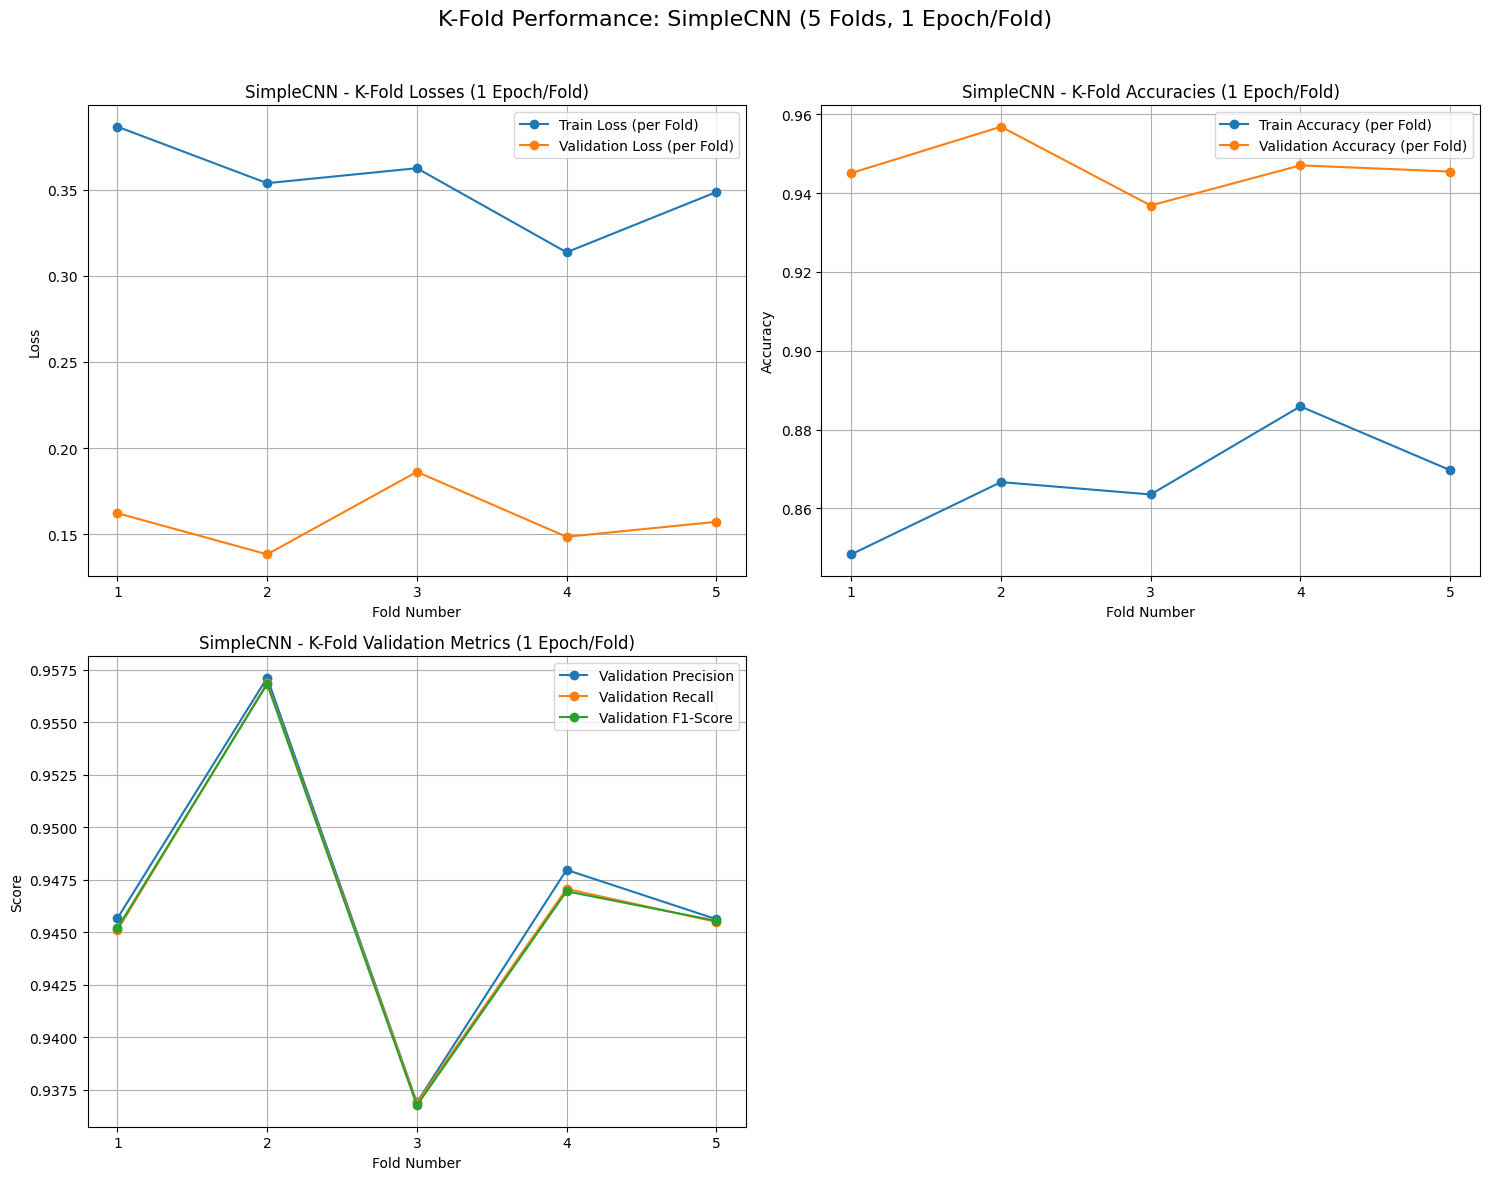


Resultados K-Fold SimpleCNN:
   fold  accuracy  precision    recall        f1
0     1  0.945098   0.945663  0.945098  0.945192
1     2  0.956863   0.957114  0.956863  0.956814
2     3  0.936863   0.936889  0.936863  0.936753
3     4  0.947059   0.947965  0.947059  0.946943
4     5  0.945490   0.945618  0.945490  0.945538

--- FIM DA CÉLULA 2: K-FOLD SimpleCNN ---


In [ ]:
# ## Validação Cruzada K-Fold

# --- CÉLULA 2: K-Fold - SimpleCNN ---
if len(train_val_dataset) >= k_folds :
    print(f"\n==================================================\nINICIANDO K-FOLD PARA SimpleCNN (Folds: {k_folds}, Épocas por fold: {kfold_epochs})\n==================================================")
    simplecnn_kfold_results, simplecnn_kfold_histories = train_kfold(SimpleCNN, train_val_dataset, k_folds, kfold_epochs, batch_size, device, "SimpleCNN")
    plot_kfold_metrics_summary("SimpleCNN", simplecnn_kfold_results, simplecnn_kfold_histories, k_folds, output_graphics_dir)
    if simplecnn_kfold_results: print(f"\nResultados K-Fold SimpleCNN:\n{pd.DataFrame(simplecnn_kfold_results)}")
else: print("\nK-Fold não executado para SimpleCNN: dados insuficientes.")
print("\n--- FIM DA CÉLULA 2: K-FOLD SimpleCNN ---")



INICIANDO K-FOLD PARA LightCNN (Folds: 5, Épocas por fold: 1)

MODEL: LightCNN - FOLD 1/5
Epoch 1/1 | Train loss: 0.9010, Train acc: 0.5688 | Val loss: 0.6757, Val acc: 0.7047
FOLD 1 VALIDATION RESULTS: Accuracy: 0.7047 - Precision: 0.6982 - Recall: 0.7047 - F1: 0.6969

MODEL: LightCNN - FOLD 2/5
Epoch 1/1 | Train loss: 0.9188, Train acc: 0.5631 | Val loss: 0.6994, Val acc: 0.6890
FOLD 2 VALIDATION RESULTS: Accuracy: 0.6890 - Precision: 0.7069 - Recall: 0.6890 - F1: 0.6870

MODEL: LightCNN - FOLD 3/5
Epoch 1/1 | Train loss: 0.8773, Train acc: 0.5780 | Val loss: 0.7153, Val acc: 0.6561
FOLD 3 VALIDATION RESULTS: Accuracy: 0.6561 - Precision: 0.6517 - Recall: 0.6561 - F1: 0.6322

MODEL: LightCNN - FOLD 4/5
Epoch 1/1 | Train loss: 0.9488, Train acc: 0.5306 | Val loss: 0.7535, Val acc: 0.6427
FOLD 4 VALIDATION RESULTS: Accuracy: 0.6427 - Precision: 0.6439 - Recall: 0.6427 - F1: 0.6258

MODEL: LightCNN - FOLD 5/5
Epoch 1/1 | Train loss: 0.9038, Train acc: 0.5425 | Val loss: 0.6979, Val acc

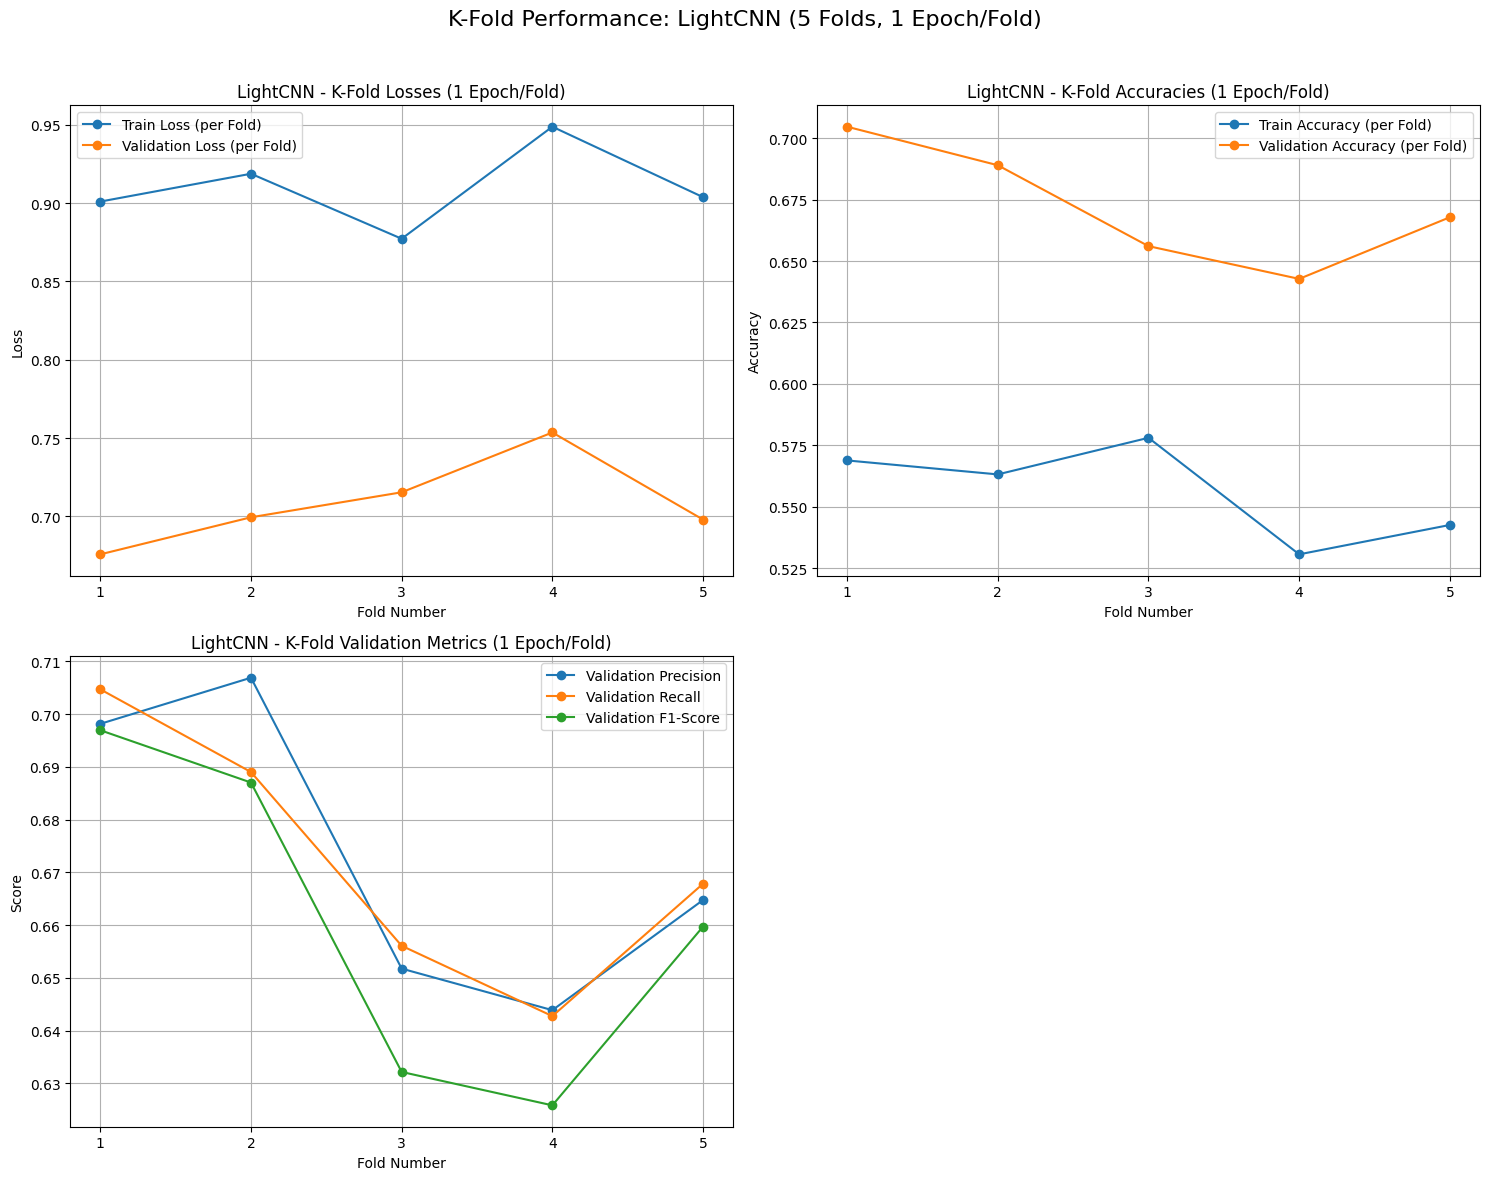


Resultados K-Fold LightCNN:
   fold  accuracy  precision    recall        f1
0     1  0.704706   0.698159  0.704706  0.696947
1     2  0.689020   0.706903  0.689020  0.687027
2     3  0.656078   0.651749  0.656078  0.632158
3     4  0.642745   0.643874  0.642745  0.625828
4     5  0.667843   0.664757  0.667843  0.659716

--- FIM DA CÉLULA 3: K-FOLD LightCNN ---


In [ ]:


# --- CÉLULA 3: K-Fold - LightCNN ---
if len(train_val_dataset) >= k_folds:
    print(f"\n==================================================\nINICIANDO K-FOLD PARA LightCNN (Folds: {k_folds}, Épocas por fold: {kfold_epochs})\n==================================================")
    lightcnn_kfold_results, lightcnn_kfold_histories = train_kfold(LightCNN, train_val_dataset, k_folds, kfold_epochs, batch_size, device, "LightCNN")
    plot_kfold_metrics_summary("LightCNN", lightcnn_kfold_results, lightcnn_kfold_histories, k_folds, output_graphics_dir)
    if lightcnn_kfold_results: print(f"\nResultados K-Fold LightCNN:\n{pd.DataFrame(lightcnn_kfold_results)}")
else: print("\nK-Fold não executado para LightCNN: dados insuficientes.")
print("\n--- FIM DA CÉLULA 3: K-FOLD LightCNN ---")






INICIANDO K-FOLD PARA MiniMobileNetV2 (Folds: 5, Épocas por fold: 1)

MODEL: MiniMobileNetV2 - FOLD 1/5
Epoch 1/1 | Train loss: 0.4418, Train acc: 0.8274 | Val loss: 0.8404, Val acc: 0.6525
FOLD 1 VALIDATION RESULTS: Accuracy: 0.6525 - Precision: 0.7953 - Recall: 0.6525 - F1: 0.6403

MODEL: MiniMobileNetV2 - FOLD 2/5
Epoch 1/1 | Train loss: 0.4197, Train acc: 0.8411 | Val loss: 0.2186, Val acc: 0.9204
FOLD 2 VALIDATION RESULTS: Accuracy: 0.9204 - Precision: 0.9236 - Recall: 0.9204 - F1: 0.9198

MODEL: MiniMobileNetV2 - FOLD 3/5
Epoch 1/1 | Train loss: 0.4306, Train acc: 0.8300 | Val loss: 0.4775, Val acc: 0.8047
FOLD 3 VALIDATION RESULTS: Accuracy: 0.8047 - Precision: 0.8656 - Recall: 0.8047 - F1: 0.8072

MODEL: MiniMobileNetV2 - FOLD 4/5
Epoch 1/1 | Train loss: 0.4302, Train acc: 0.8329 | Val loss: 0.3996, Val acc: 0.8396
FOLD 4 VALIDATION RESULTS: Accuracy: 0.8396 - Precision: 0.8738 - Recall: 0.8396 - F1: 0.8413

MODEL: MiniMobileNetV2 - FOLD 5/5
Epoch 1/1 | Train loss: 0.4304, Tra

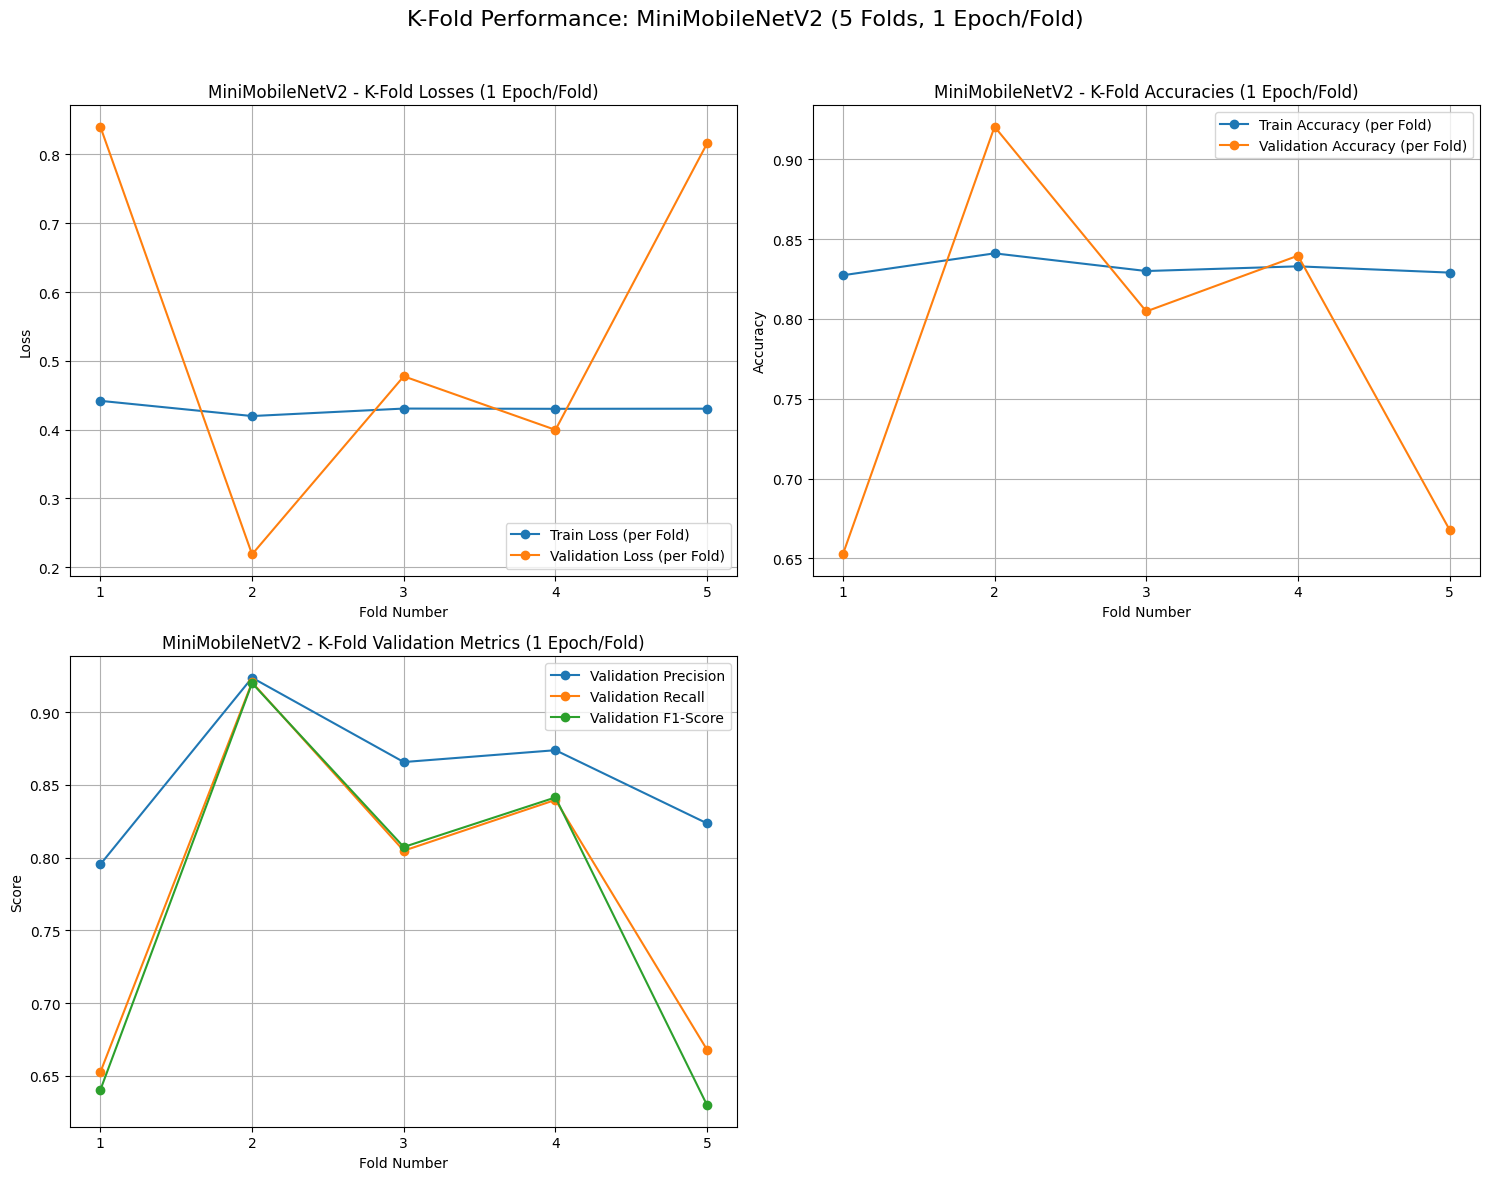


Resultados K-Fold MiniMobileNetV2:
   fold  accuracy  precision    recall        f1
0     1  0.652549   0.795321  0.652549  0.640318
1     2  0.920392   0.923565  0.920392  0.919835
2     3  0.804706   0.865617  0.804706  0.807247
3     4  0.839608   0.873763  0.839608  0.841321
4     5  0.667843   0.823466  0.667843  0.629751

--- FIM DA CÉLULA 4: K-FOLD MiniMobileNetV2 ---


In [ ]:
# --- CÉLULA 4: K-Fold - MiniMobileNetV2 ---
if len(train_val_dataset) >= k_folds:
    print(f"\n==================================================\nINICIANDO K-FOLD PARA MiniMobileNetV2 (Folds: {k_folds}, Épocas por fold: {kfold_epochs})\n==================================================")
    minimbnet_kfold_results, minimbnet_kfold_histories = train_kfold(MiniMobileNetV2, train_val_dataset, k_folds, kfold_epochs, batch_size, device, "MiniMobileNetV2")
    plot_kfold_metrics_summary("MiniMobileNetV2", minimbnet_kfold_results, minimbnet_kfold_histories, k_folds, output_graphics_dir)
    if minimbnet_kfold_results: print(f"\nResultados K-Fold MiniMobileNetV2:\n{pd.DataFrame(minimbnet_kfold_results)}")
else: print("\nK-Fold não executado para MiniMobileNetV2: dados insuficientes.")
print("\n--- FIM DA CÉLULA 4: K-FOLD MiniMobileNetV2 ---")





INICIANDO TREINAMENTO INDIVIDUAL PARA SimpleCNN (20 épocas)

--- Treinando SimpleCNN individualmente por 20 épocas ---
Divisão interna: 10200 treino, 2550 validação.
Modelo: SimpleCNN - Época 1/20 | Perda Treino: 0.3315, Acurácia Treino: 0.8735 | Perda Val: 0.1406, Acurácia Val: 0.9514
Modelo: SimpleCNN - Época 2/20 | Perda Treino: 0.1464, Acurácia Treino: 0.9519 | Perda Val: 0.1194, Acurácia Val: 0.9553
Modelo: SimpleCNN - Época 3/20 | Perda Treino: 0.0985, Acurácia Treino: 0.9678 | Perda Val: 0.0939, Acurácia Val: 0.9667
Modelo: SimpleCNN - Época 4/20 | Perda Treino: 0.0670, Acurácia Treino: 0.9761 | Perda Val: 0.0910, Acurácia Val: 0.9710
Modelo: SimpleCNN - Época 5/20 | Perda Treino: 0.0553, Acurácia Treino: 0.9804 | Perda Val: 0.0806, Acurácia Val: 0.9745
Modelo: SimpleCNN - Época 6/20 | Perda Treino: 0.0473, Acurácia Treino: 0.9841 | Perda Val: 0.0958, Acurácia Val: 0.9714
Modelo: SimpleCNN - Época 7/20 | Perda Treino: 0.0377, Acurácia Treino: 0.9872 | Perda Val: 0.0719, Acuráci

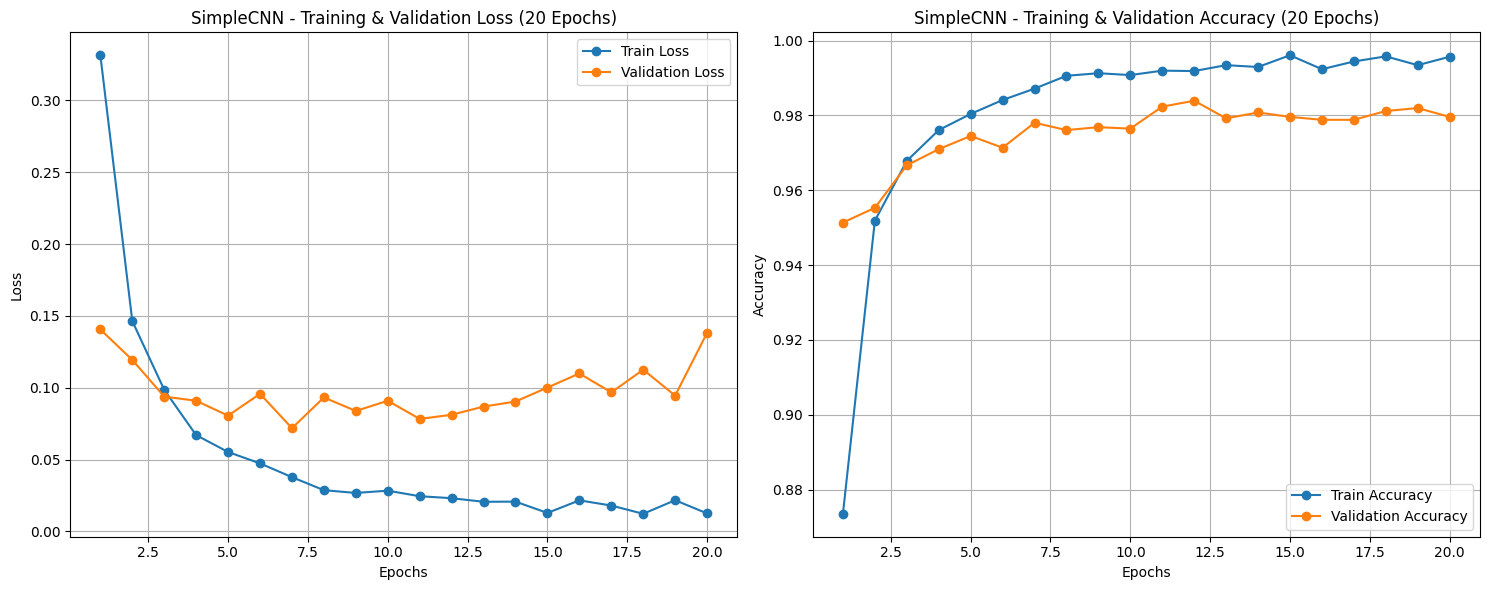

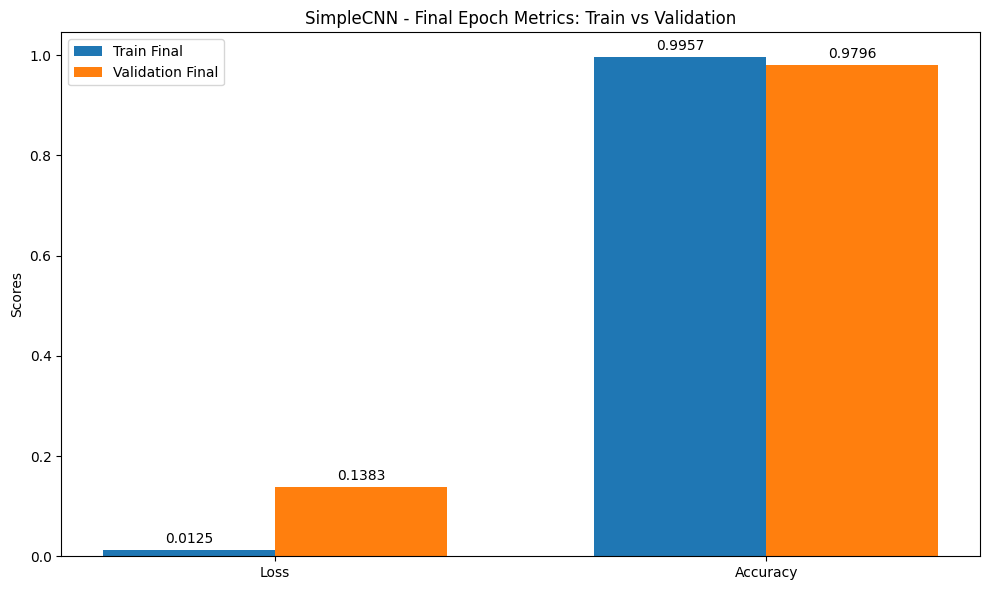


Avaliando SimpleCNN (treinado individualmente) no conjunto de teste FINAL...
SimpleCNN - RESULTADOS DO TESTE FINAL:
Acurácia: 0.9800 - Precisão: 0.9800 - Recall: 0.9800 - F1-Score: 0.9800


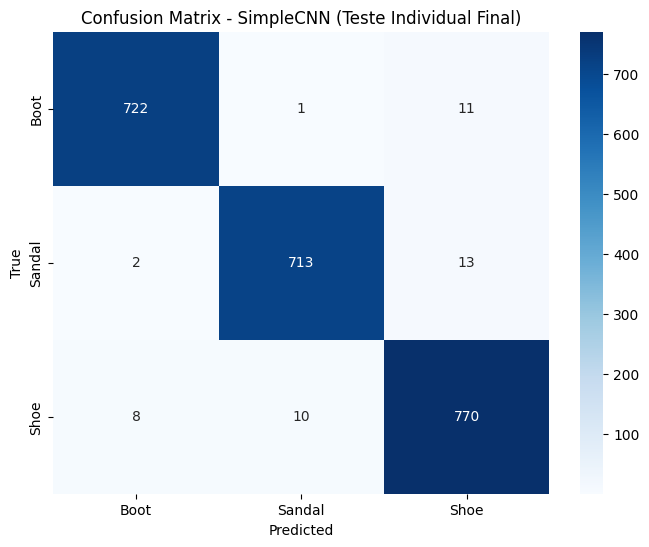


--- FIM DA CÉLULA 5: TREINAMENTO INDIVIDUAL SimpleCNN ---


In [ ]:
# ## Treinamento Individual de Modelos

# --- CÉLULA 5: Treinamento Individual - SimpleCNN ---
if len(train_val_dataset) > 0:
    print(f"\n==================================================\nINICIANDO TREINAMENTO INDIVIDUAL PARA SimpleCNN ({individual_train_epochs} épocas)\n==================================================")
    _, simplecnn_test_metrics = train_evaluate_individual_model(SimpleCNN, "SimpleCNN", train_val_dataset, test_loader, device, individual_train_epochs, batch_size, output_graphics_dir)
    if simplecnn_test_metrics: all_models_final_test_metrics["SimpleCNN"] = simplecnn_test_metrics
else: print("\nTreinamento individual não executado para SimpleCNN: dados insuficientes.")
print("\n--- FIM DA CÉLULA 5: TREINAMENTO INDIVIDUAL SimpleCNN ---")





INICIANDO TREINAMENTO INDIVIDUAL PARA LightCNN (20 épocas)

--- Treinando LightCNN individualmente por 20 épocas ---
Divisão interna: 10200 treino, 2550 validação.
Modelo: LightCNN - Época 1/20 | Perda Treino: 0.8768, Acurácia Treino: 0.5781 | Perda Val: 0.7015, Acurácia Val: 0.6737
Modelo: LightCNN - Época 2/20 | Perda Treino: 0.6082, Acurácia Treino: 0.7204 | Perda Val: 0.5520, Acurácia Val: 0.7482
Modelo: LightCNN - Época 3/20 | Perda Treino: 0.5175, Acurácia Treino: 0.7764 | Perda Val: 0.4582, Acurácia Val: 0.8169
Modelo: LightCNN - Época 4/20 | Perda Treino: 0.4465, Acurácia Treino: 0.8165 | Perda Val: 0.4301, Acurácia Val: 0.8141
Modelo: LightCNN - Época 5/20 | Perda Treino: 0.4006, Acurácia Treino: 0.8412 | Perda Val: 0.3794, Acurácia Val: 0.8545
Modelo: LightCNN - Época 6/20 | Perda Treino: 0.3688, Acurácia Treino: 0.8544 | Perda Val: 0.3623, Acurácia Val: 0.8557
Modelo: LightCNN - Época 7/20 | Perda Treino: 0.3334, Acurácia Treino: 0.8738 | Perda Val: 0.3352, Acurácia Val: 0.

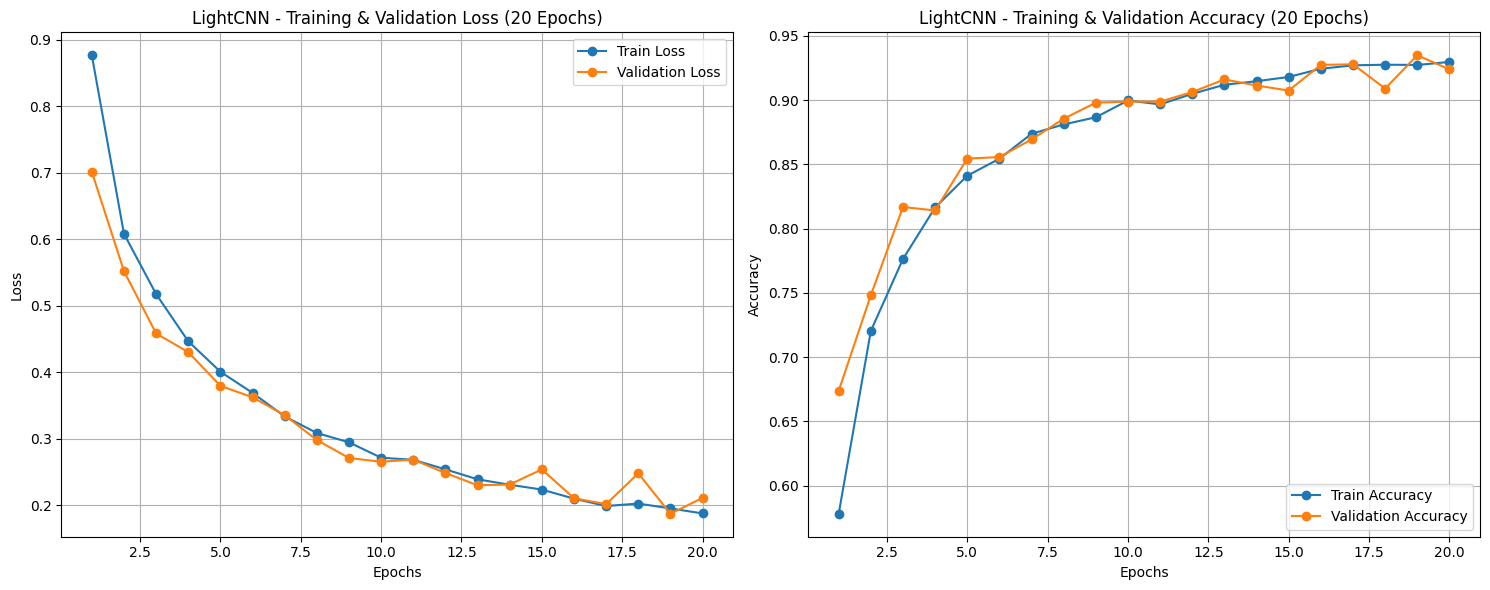

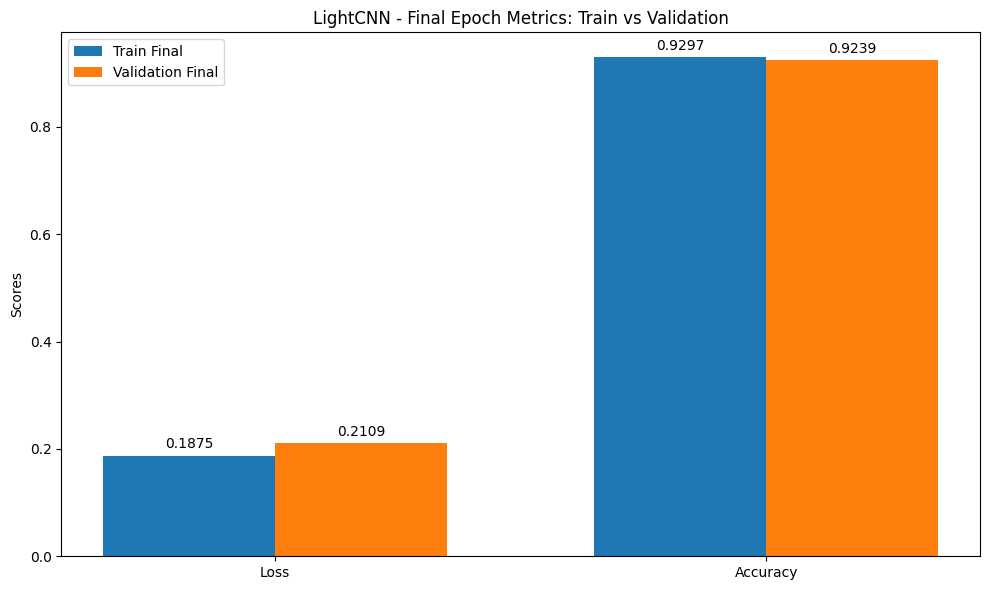


Avaliando LightCNN (treinado individualmente) no conjunto de teste FINAL...
LightCNN - RESULTADOS DO TESTE FINAL:
Acurácia: 0.9196 - Precisão: 0.9234 - Recall: 0.9196 - F1-Score: 0.9199


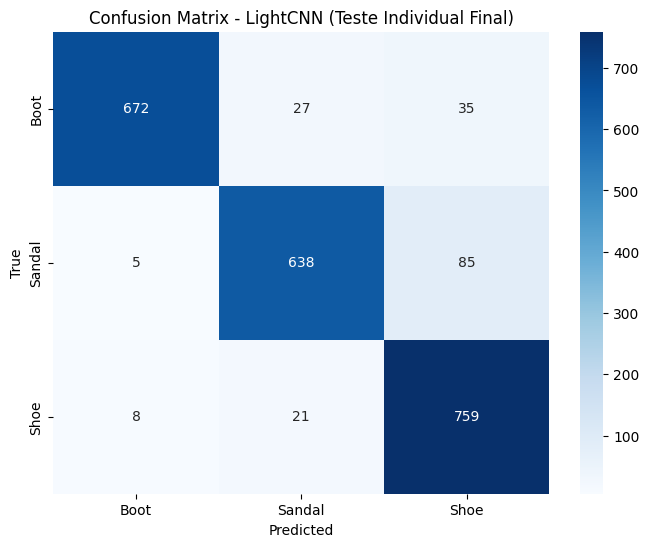


--- FIM DA CÉLULA 6: TREINAMENTO INDIVIDUAL LightCNN ---


In [ ]:
# --- CÉLULA 6: Treinamento Individual - LightCNN ---
if len(train_val_dataset) > 0:
    print(f"\n==================================================\nINICIANDO TREINAMENTO INDIVIDUAL PARA LightCNN ({individual_train_epochs} épocas)\n==================================================")
    _, lightcnn_test_metrics = train_evaluate_individual_model(LightCNN, "LightCNN", train_val_dataset, test_loader, device, individual_train_epochs, batch_size, output_graphics_dir)
    if lightcnn_test_metrics: all_models_final_test_metrics["LightCNN"] = lightcnn_test_metrics
else: print("\nTreinamento individual não executado para LightCNN: dados insuficientes.")
print("\n--- FIM DA CÉLULA 6: TREINAMENTO INDIVIDUAL LightCNN ---")




INICIANDO TREINAMENTO INDIVIDUAL PARA MiniMobileNetV2 (20 épocas)

--- Treinando MiniMobileNetV2 individualmente por 20 épocas ---
Divisão interna: 10200 treino, 2550 validação.
Modelo: MiniMobileNetV2 - Época 1/20 | Perda Treino: 0.4224, Acurácia Treino: 0.8422 | Perda Val: 0.7601, Acurácia Val: 0.6600
Modelo: MiniMobileNetV2 - Época 2/20 | Perda Treino: 0.1953, Acurácia Treino: 0.9342 | Perda Val: 0.1482, Acurácia Val: 0.9463
Modelo: MiniMobileNetV2 - Época 3/20 | Perda Treino: 0.1459, Acurácia Treino: 0.9473 | Perda Val: 0.1373, Acurácia Val: 0.9545
Modelo: MiniMobileNetV2 - Época 4/20 | Perda Treino: 0.1152, Acurácia Treino: 0.9610 | Perda Val: 0.5051, Acurácia Val: 0.8137
Modelo: MiniMobileNetV2 - Época 5/20 | Perda Treino: 0.0968, Acurácia Treino: 0.9678 | Perda Val: 0.1252, Acurácia Val: 0.9608
Modelo: MiniMobileNetV2 - Época 6/20 | Perda Treino: 0.0892, Acurácia Treino: 0.9687 | Perda Val: 0.1460, Acurácia Val: 0.9482
Modelo: MiniMobileNetV2 - Época 7/20 | Perda Treino: 0.0733

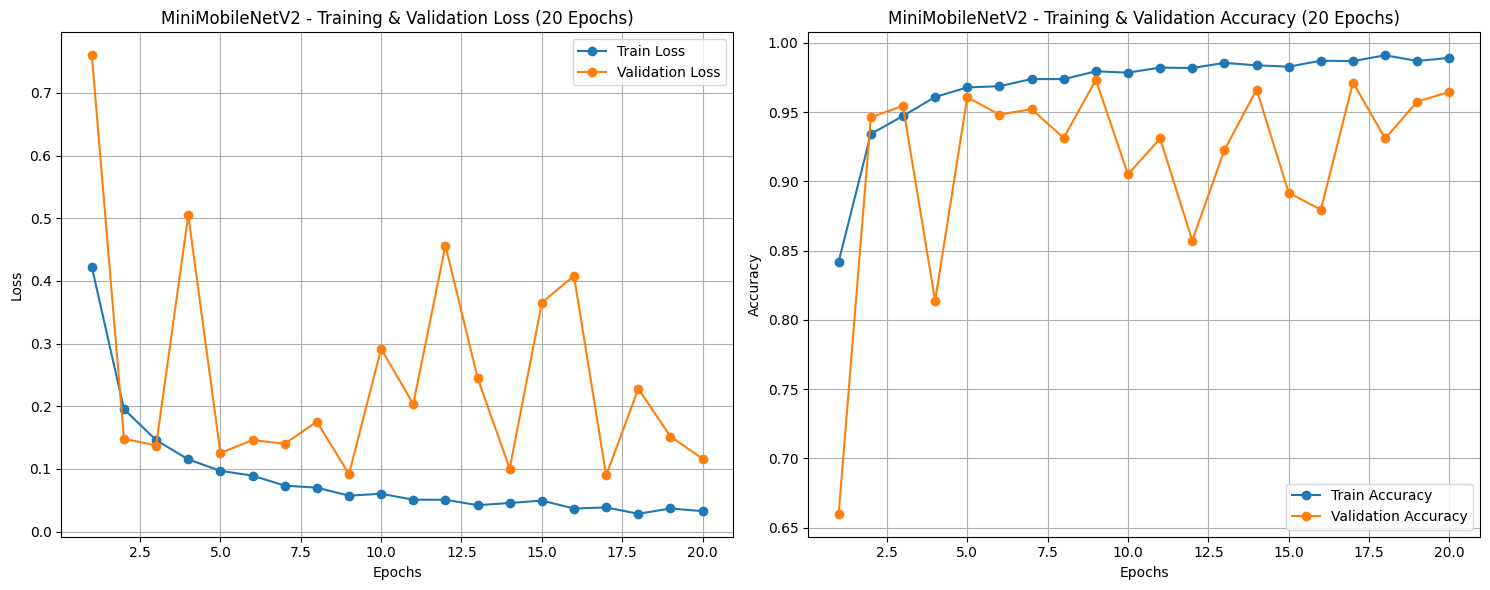

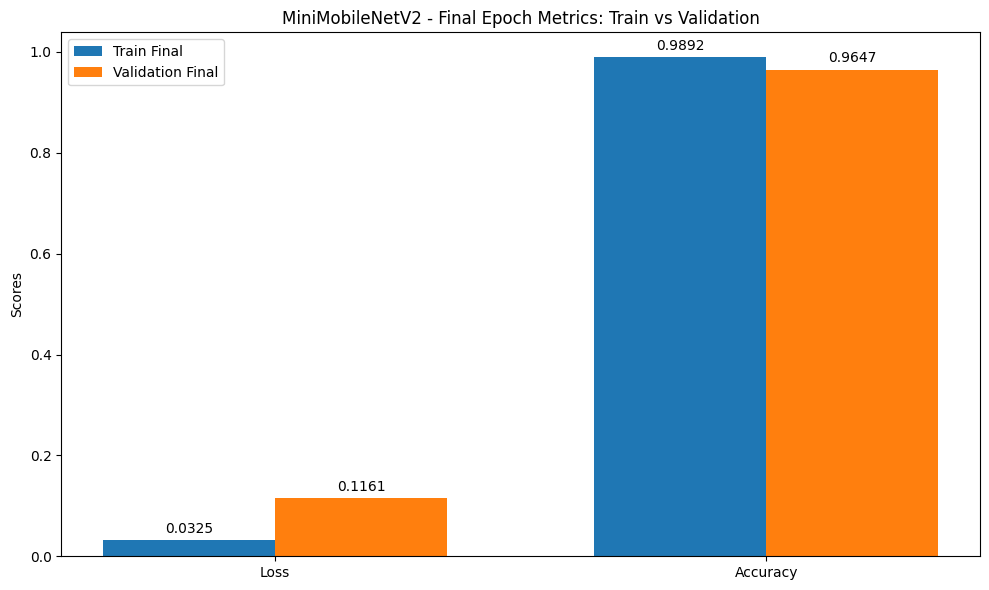


Avaliando MiniMobileNetV2 (treinado individualmente) no conjunto de teste FINAL...
MiniMobileNetV2 - RESULTADOS DO TESTE FINAL:
Acurácia: 0.9609 - Precisão: 0.9612 - Recall: 0.9609 - F1-Score: 0.9607


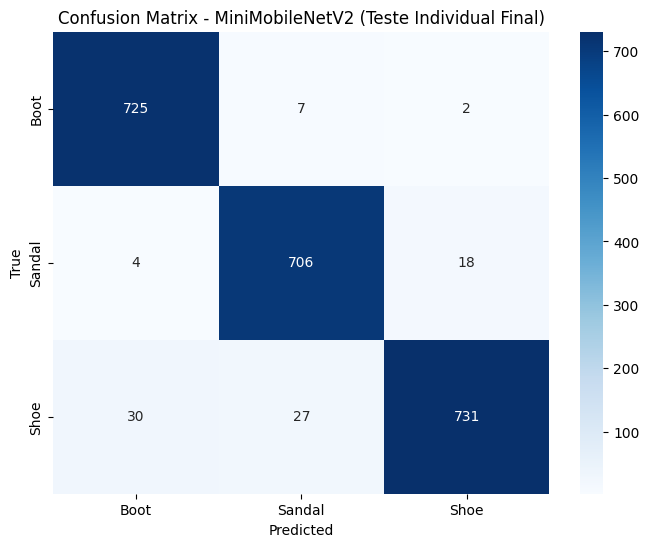


--- FIM DA CÉLULA 7: TREINAMENTO INDIVIDUAL MiniMobileNetV2 ---


In [ ]:
# --- CÉLULA 7: Treinamento Individual - MiniMobileNetV2 ---
if len(train_val_dataset) > 0:
    print(f"\n==================================================\nINICIANDO TREINAMENTO INDIVIDUAL PARA MiniMobileNetV2 ({individual_train_epochs} épocas)\n==================================================")
    _, minimbnet_test_metrics = train_evaluate_individual_model(MiniMobileNetV2, "MiniMobileNetV2", train_val_dataset, test_loader, device, individual_train_epochs, batch_size, output_graphics_dir)
    if minimbnet_test_metrics: all_models_final_test_metrics["MiniMobileNetV2"] = minimbnet_test_metrics
else: print("\nTreinamento individual não executado para MiniMobileNetV2: dados insuficientes.")
print("\n--- FIM DA CÉLULA 7: TREINAMENTO INDIVIDUAL MiniMobileNetV2 ---")




GERANDO GRÁFICO DE COMPARAÇÃO FINAL DOS MODELOS (MÉTRICAS DE TESTE)


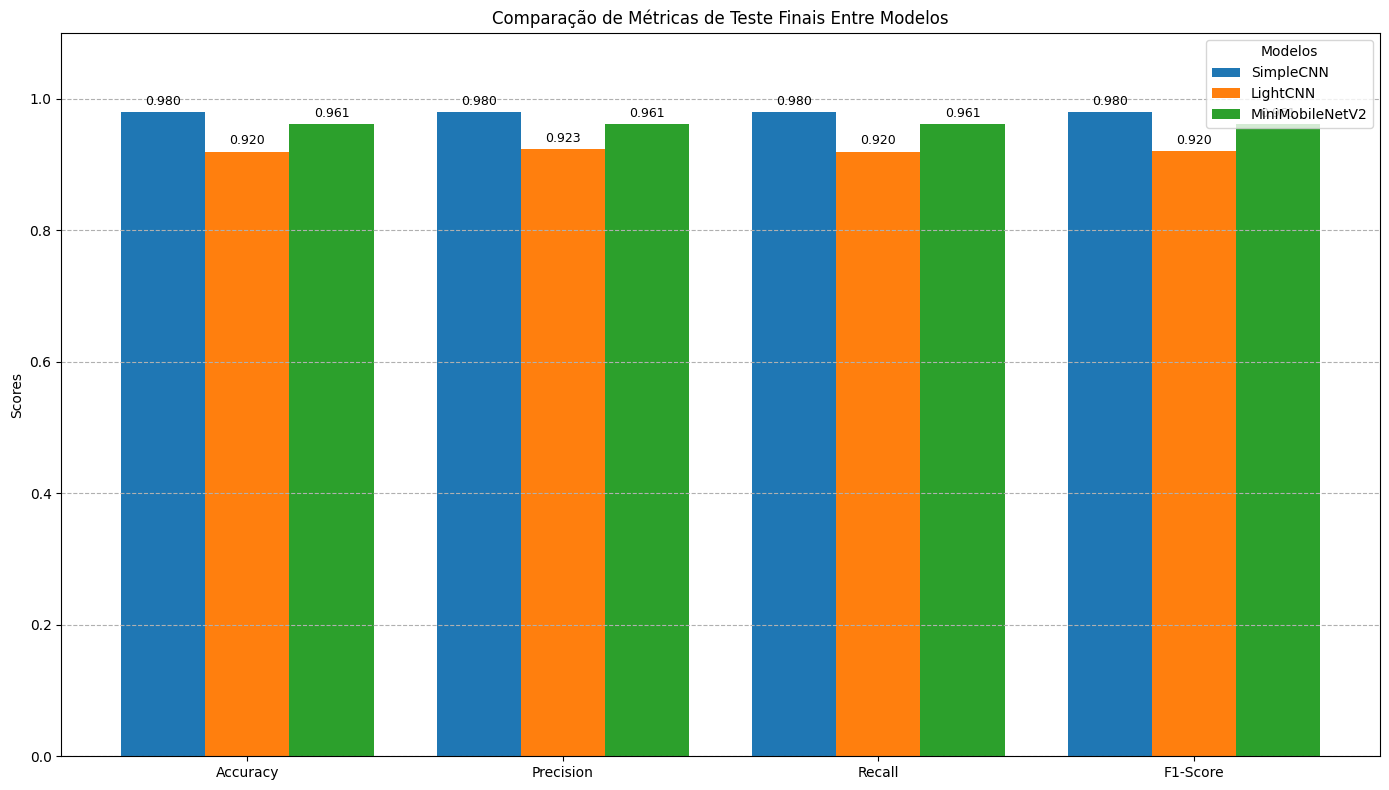


--- FIM DA CÉLULA 8: COMPARAÇÃO FINAL DOS MODELOS ---


In [ ]:
# ## Comparação Final dos Modelos (Métricas de Teste)
# Esta seção exibe um gráfico de barras comparando as métricas de desempenho (Acurácia, Precisão, Recall, F1-Score)
# dos três modelos no conjunto de teste final.

# --- CÉLULA 8: Comparação Final dos Modelos (Métricas de Teste) ---
print(f"\n==================================================")
print(f"GERANDO GRÁFICO DE COMPARAÇÃO FINAL DOS MODELOS (MÉTRICAS DE TESTE)")
print(f"==================================================")

if all_models_final_test_metrics and len(all_models_final_test_metrics) > 0:
    model_names_for_plot = list(all_models_final_test_metrics.keys())
    # Filtrar modelos que realmente têm métricas (não apenas chaves com valores padrão de 0 se o teste não rodou)
    valid_metrics_to_plot = {k: v for k, v in all_models_final_test_metrics.items() if any(m_val > 0 for m_val in v.values())}
    if valid_metrics_to_plot:
        plot_model_comparison_test_metrics_bar_chart(list(valid_metrics_to_plot.keys()), valid_metrics_to_plot)
    else:
        print("Nenhuma métrica de teste válida (diferente de zero) encontrada para os modelos. Gráfico de comparação não será gerado.")
else:
    print("Nenhuma métrica de teste final coletada para os modelos. Gráfico de comparação não será gerado.")

print("\n--- FIM DA CÉLULA 8: COMPARAÇÃO FINAL DOS MODELOS ---")


